# Baseline Traditional Models

Train Linear Regression, Ridge Regression, and Support Vector Regression on the feature-selected dataset. Hyperparameter tuning via GridSearchCV with K-Fold cross-validation. Evaluation metrics: RMSE, MAE, R².

## Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_SEED = 42
DATA_PATH = os.path.join("..", "data", "after_Feature_Selection", "rf_selected_classic.csv")
MODELS_DIR = os.path.join("..", "models")
REPORTS_DIR = os.path.join("..", "reports")
TARGET_COL = "Paddy yield(in Kg)"

os.makedirs(MODELS_DIR, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2789, 16)


,Micronutrients_70Days,Potassh_50Days,Nursery area (Cents),Seedrate(in Kg),Hectares,Urea_40Days,Weed28D_thiobencarb,DAP_20days,Pest_60Day(in ml),LP_Mainfield(in Tonnes),Trash(in bundles),Soil Types_clay,Nursery_wet,Variety_ponmani,Variety_delux ponni,Paddy yield(in Kg)
0,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.522734,0.0,0.0,0.0,0.0,35028
1,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.969526,1.0,1.0,1.0,0.0,35412
2,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.969526,0.0,0.0,0.0,1.0,36300
3,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.522734,1.0,1.0,0.0,0.0,35016
4,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.969526,0.0,0.0,1.0,0.0,34044


In [3]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 2231 samples
Test set:     558 samples


## K-Fold Cross-Validation & Evaluation Helper

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

results = []

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv):
    """Run K-fold CV on training data, then evaluate on held-out test set."""
    scoring = {
        "neg_rmse": "neg_root_mean_squared_error",
        "neg_mae": "neg_mean_absolute_error",
        "r2": "r2",
    }
    cv_scores = cross_validate(model, X_tr, y_tr, cv=cv, scoring=scoring)

    cv_rmse = -cv_scores["test_neg_rmse"].mean()
    cv_mae  = -cv_scores["test_neg_mae"].mean()
    cv_r2   =  cv_scores["test_r2"].mean()

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    test_mae  = mean_absolute_error(y_te, y_pred)
    test_r2   = r2_score(y_te, y_pred)

    row = {
        "Model": name,
        "CV RMSE": cv_rmse, "CV MAE": cv_mae, "CV R²": cv_r2,
        "Test RMSE": test_rmse, "Test MAE": test_mae, "Test R²": test_r2,
    }
    results.append(row)

    print(f"--- {name} ---")
    print(f"  CV   | RMSE: {cv_rmse:.2f}  MAE: {cv_mae:.2f}  R²: {cv_r2:.4f}")
    print(f"  Test | RMSE: {test_rmse:.2f}  MAE: {test_mae:.2f}  R²: {test_r2:.4f}\n")

    return model

## Model 1: Linear Regression

In [5]:
lr_model = evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train, y_train, X_test, y_test, kf
)

--- Linear Regression ---
  CV   | RMSE: 936.24  MAE: 712.71  R²: 0.9897
  Test | RMSE: 928.66  MAE: 698.10  R²: 0.9894



## Model 2: Ridge Regression (with Hyperparameter Tuning)

In [6]:
ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    refit=True,
)
ridge_grid.fit(X_train, y_train)

print(f"Best Ridge alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best CV RMSE:     {-ridge_grid.best_score_:.2f}\n")

ridge_model = evaluate_model(
    "Ridge Regression",
    ridge_grid.best_estimator_,
    X_train, y_train, X_test, y_test, kf
)

Best Ridge alpha: 0.01
Best CV RMSE:     936.24

--- Ridge Regression ---
  CV   | RMSE: 936.24  MAE: 712.71  R²: 0.9897
  Test | RMSE: 928.67  MAE: 698.11  R²: 0.9894



## Model 3: Support Vector Regression (with Hyperparameter Tuning)

In [7]:
svr_params = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5],
    "kernel": ["rbf", "linear"],
}

svr_grid = GridSearchCV(
    SVR(),
    svr_params,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    refit=True,
    n_jobs=-1,
)
svr_grid.fit(X_train, y_train)

print(f"Best SVR params: {svr_grid.best_params_}")
print(f"Best CV RMSE:    {-svr_grid.best_score_:.2f}\n")

svr_model = evaluate_model(
    "SVR",
    svr_grid.best_estimator_,
    X_train, y_train, X_test, y_test, kf
)

Best SVR params: {'C': 100, 'epsilon': 0.01, 'kernel': 'linear'}
Best CV RMSE:    958.04



--- SVR ---
  CV   | RMSE: 958.04  MAE: 706.55  R²: 0.9892
  Test | RMSE: 958.21  MAE: 703.19  R²: 0.9887



## Results Comparison

In [8]:
results_df = pd.DataFrame(results).set_index("Model")
results_df.style.format("{:.4f}").highlight_min(
    subset=["CV RMSE", "CV MAE", "Test RMSE", "Test MAE"], color="lightgreen"
).highlight_max(
    subset=["CV R²", "Test R²"], color="lightgreen"
)

,CV RMSE,CV MAE,CV R²,Test RMSE,Test MAE,Test R²
Model,,,,,,
Linear Regression,936.2397,712.7114,0.9897,928.6632,698.1047,0.9894
Ridge Regression,936.2396,712.7051,0.9897,928.6662,698.1054,0.9894
SVR,958.0415,706.5462,0.9892,958.2080,703.1897,0.9887


## Visualizations

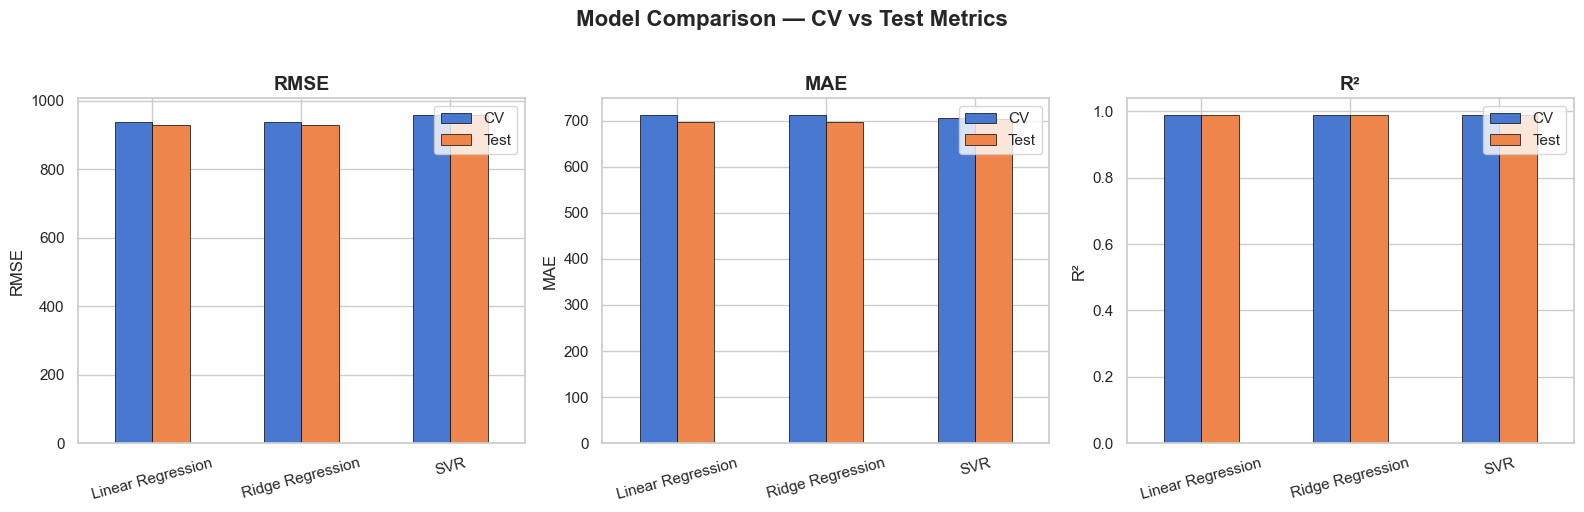

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, higher_better) in zip(axes, [("RMSE", False), ("MAE", False), ("R²", True)]):
    cv_col, test_col = f"CV {metric}", f"Test {metric}"
    plot_df = results_df[[cv_col, test_col]].rename(columns={cv_col: "CV", test_col: "Test"})
    plot_df.plot.bar(ax=ax, rot=15, edgecolor="black", linewidth=0.5)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    ax.legend(frameon=True)

plt.suptitle("Model Comparison — CV vs Test Metrics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "baseline_metrics_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

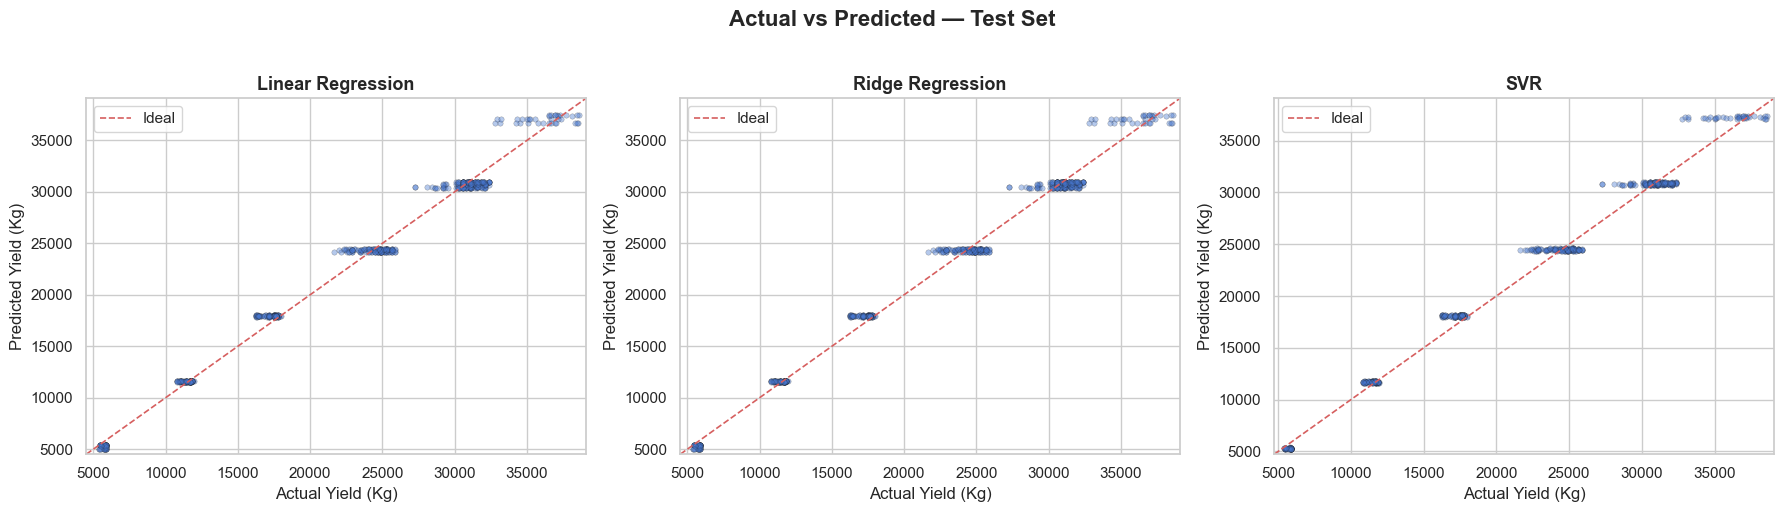

In [10]:
trained_models = {
    "Linear Regression": lr_model,
    "Ridge Regression": ridge_model,
    "SVR": svr_model,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, edgecolors="k", linewidths=0.3)
    lims = [min(y_test.min(), y_pred.min()) - 500, max(y_test.max(), y_pred.max()) + 500]
    ax.plot(lims, lims, "r--", linewidth=1.2, label="Ideal")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual Yield (Kg)")
    ax.set_ylabel("Predicted Yield (Kg)")
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.legend(loc="upper left")

plt.suptitle("Actual vs Predicted — Test Set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "baseline_actual_vs_predicted.png"), dpi=150, bbox_inches="tight")
plt.show()

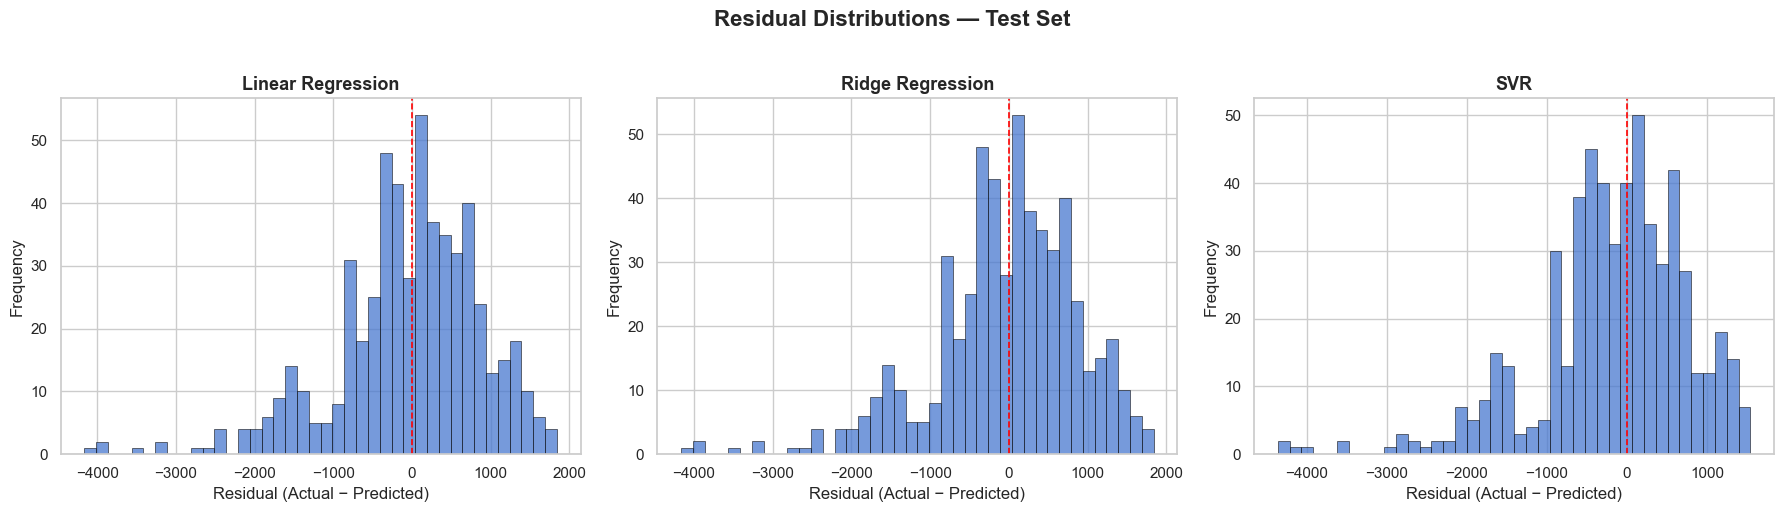

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    residuals = y_test - model.predict(X_test)
    ax.hist(residuals, bins=40, edgecolor="black", linewidth=0.5, alpha=0.75)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Residual (Actual − Predicted)")
    ax.set_ylabel("Frequency")
    ax.set_title(name, fontsize=13, fontweight="bold")

plt.suptitle("Residual Distributions — Test Set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "baseline_residual_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save Models

In [12]:
models_to_save = {
    "linear_regression.pkl": lr_model,
    "ridge_regression.pkl": ridge_model,
    "svr.pkl": svr_model,
}

for filename, model in models_to_save.items():
    path = os.path.join(MODELS_DIR, filename)
    joblib.dump(model, path)
    print(f"Saved {filename} -> {path}")

Saved linear_regression.pkl -> ../models/linear_regression.pkl
Saved ridge_regression.pkl -> ../models/ridge_regression.pkl
Saved svr.pkl -> ../models/svr.pkl
